# 06 Encoding Contextual Complete — Pseudo-Sentence Embeddings + Noise Controls

This notebook runs ECoG encoding on the pseudo-sentence contextual embeddings and includes noise control conditions.

Main conditions:
- English contextual
- Hebrew contextual
- Arabic contextual
- English + Hebrew contextual
- English + Arabic contextual
- English + Hebrew + Arabic contextual

Noise controls:
- Noise only
- English + Noise
- English + Noise + Noise

The noise controls help test whether improvements in combined conditions come from meaningful linguistic information or just from adding more feature dimensions.


In [1]:
# =========================
# Cell 1: Imports
# =========================

import os
import json
from datetime import datetime
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mne
from tqdm.auto import tqdm

from himalaya.backend import set_backend, get_backend
from himalaya.ridge import RidgeCV
from himalaya.scoring import correlation_score

from sklearn.model_selection import KFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import ttest_rel, wilcoxon

# Backend selection
try:
    import torch
    if torch.cuda.is_available():
        set_backend("torch_cuda")
        print("Himalaya backend: Using CUDA (GPU)")
    else:
        set_backend("torch")
        print("Himalaya backend: Using Torch (CPU)")
except ImportError:
    set_backend("numpy")
    print("Himalaya backend: Using Numpy (CPU)")

print("Imports ready.")

c:\Users\mayat\miniconda3\envs\language_project_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Himalaya backend: Using Torch (CPU)
Imports ready.


In [2]:
# =========================
# Cell 2: Paths and configuration
# =========================

PROJECT_ROOT = r"C:\Users\mayat\OneDrive\Desktop\lab\Language-Project-main"

WORD_LEVEL_PATH = rf"{PROJECT_ROOT}\data\Amirim_Project_Submission\Amirim_Project_Submission\translated_podcast_transcript_filtered.csv"

# Folder containing the contextual embeddings generated from pseudo-sentences
EMBEDDINGS_DIR = rf"{PROJECT_ROOT}\data\processed\PseudoSentencesEmbeddings"

EN_EMBED_PATH = os.path.join(EMBEDDINGS_DIR, "en_pseudo_sentence_word_context_embeddings.npy")
HE_EMBED_PATH = os.path.join(EMBEDDINGS_DIR, "he_pseudo_sentence_word_context_embeddings.npy")
AR_EMBED_PATH = os.path.join(EMBEDDINGS_DIR, "ar_pseudo_sentence_word_context_embeddings.npy")

# ECoG directory
ECOGPREP_DIR = r"C:\Users\mayat\ds005574-download\derivatives\ecogprep"

# Encoding parameters
freq = 32
tmin, tmax = -1.0, 1.0

# PCA is recommended for high-dimensional combined contextual embeddings.
# Start with False if you want to match previous runs exactly.
# Then try True, PCA_dim=150 as a second run.
use_PCA = True
PCA_dim = 150

# Start with one subject for testing.
# After the test works, change to: subjects = [f"{i:02d}" for i in range(1, 10)]
subjects = [f"{i:02d}" for i in range(1, 10)]

# Random seed for reproducible noise controls
NOISE_SEED = 42
NOISE_MODE = "global"   # "global" or "per_row"

OUT_DIR = rf"{PROJECT_ROOT}\data\processed\encoding_results_contextual_pseudo_sentence_WITH_NOISE_{freq}Hz_({tmin},{tmax})"
os.makedirs(OUT_DIR, exist_ok=True)

print("WORD_LEVEL_PATH:", WORD_LEVEL_PATH)
print("EMBEDDINGS_DIR:", EMBEDDINGS_DIR)
print("ECOGPREP_DIR:", ECOGPREP_DIR)
print("OUT_DIR:", OUT_DIR)
print("subjects:", subjects)

WORD_LEVEL_PATH: C:\Users\mayat\OneDrive\Desktop\lab\Language-Project-main\data\Amirim_Project_Submission\Amirim_Project_Submission\translated_podcast_transcript_filtered.csv
EMBEDDINGS_DIR: C:\Users\mayat\OneDrive\Desktop\lab\Language-Project-main\data\processed\PseudoSentencesEmbeddings
ECOGPREP_DIR: C:\Users\mayat\ds005574-download\derivatives\ecogprep
OUT_DIR: C:\Users\mayat\OneDrive\Desktop\lab\Language-Project-main\data\processed\encoding_results_contextual_pseudo_sentence_WITH_NOISE_32Hz_(-1.0,1.0)
subjects: ['01', '02', '03', '04', '05', '06', '07', '08', '09']


In [3]:
# =========================
# Cell 3: Load embeddings and verify shapes
# =========================

word_level_df = pd.read_csv(WORD_LEVEL_PATH)[["start", "end", "en", "he", "ar"]].reset_index(drop=True)

E = np.load(EN_EMBED_PATH).astype(np.float32)
H = np.load(HE_EMBED_PATH).astype(np.float32)
A = np.load(AR_EMBED_PATH).astype(np.float32)

print("Words:", len(word_level_df))
print("English:", E.shape)
print("Hebrew :", H.shape)
print("Arabic :", A.shape)

assert E.shape == H.shape == A.shape, "Shape mismatch between contextual embedding matrices"
assert E.shape[0] == len(word_level_df), "Embeddings must have same number of rows as word_level_df"
assert E.shape[1] == 768, "Expected XLM-R embeddings with 768 dimensions"

print("\nAll contextual embedding shapes verified ✓")

Words: 1735
English: (1735, 768)
Hebrew : (1735, 768)
Arabic : (1735, 768)

All contextual embedding shapes verified ✓


In [4]:
# =========================
# Cell 4: Create reproducible noise matrices
# =========================

def make_noise_like(X, seed=42, mode="global"):
    """
    Create a noise matrix with the same shape as X.

    mode="global":
        Draw noise from one normal distribution using the global mean/std of X.

    mode="per_row":
        Draw each row from a normal distribution using that row's mean/std.
    """
    rng = np.random.default_rng(seed)

    if mode == "per_row":
        row_means = X.mean(axis=1, keepdims=True)
        row_stds = X.std(axis=1, keepdims=True)
        row_stds = np.where(row_stds == 0, 1.0, row_stds)
        noise = rng.normal(row_means, row_stds, size=X.shape)
    else:
        g_mean = float(X.mean())
        g_std = float(X.std())
        if g_std == 0:
            g_std = 1.0
        noise = rng.normal(g_mean, g_std, size=X.shape)

    return noise.astype(np.float32)

# Two independent noise blocks.
# N1 is used for English + Noise, matching English + Hebrew / English + Arabic.
# N1+N2 is used for English + Noise + Noise, matching English + Hebrew + Arabic.
N1 = make_noise_like(E, seed=NOISE_SEED, mode=NOISE_MODE)
N2 = make_noise_like(E, seed=NOISE_SEED + 1, mode=NOISE_MODE)

print("Noise 1:", N1.shape, "mean:", N1.mean(), "std:", N1.std())
print("Noise 2:", N2.shape, "mean:", N2.mean(), "std:", N2.std())

Noise 1: (1735, 768) mean: 0.026061757 std: 0.68890214
Noise 2: (1735, 768) mean: 0.025071017 std: 0.6895377


In [5]:
# =========================
# Cell 5: Build condition matrices
# =========================

CONDITIONS = [
    # Single-language contextual conditions
    ("English contextual", "en", E),
    ("Hebrew contextual", "he", H),
    ("Arabic contextual", "ar", A),

    # Multilingual contextual conditions
    ("English + Hebrew contextual", "en_plus_he", np.hstack([E, H]).astype(np.float32)),
    ("English + Arabic contextual", "en_plus_ar", np.hstack([E, A]).astype(np.float32)),
    ("English + Hebrew + Arabic contextual", "all", np.hstack([E, H, A]).astype(np.float32)),

    # Noise controls
    ("Noise contextual", "noise", N1),
    ("English + Noise contextual", "en_plus_noise", np.hstack([E, N1]).astype(np.float32)),
    ("English + Noise + Noise contextual", "en_plus_noise_plus_noise", np.hstack([E, N1, N2]).astype(np.float32)),
]

print("Conditions:")
for name, mode, X in CONDITIONS:
    print(f"{name:45s} | {mode:28s} | X shape = {X.shape}")

print("\nDimension checks:")
print("English + Hebrew:", np.hstack([E, H]).shape)
print("English + Noise :", np.hstack([E, N1]).shape)
print("All languages   :", np.hstack([E, H, A]).shape)
print("EN + N + N      :", np.hstack([E, N1, N2]).shape)

Conditions:
English contextual                            | en                           | X shape = (1735, 768)
Hebrew contextual                             | he                           | X shape = (1735, 768)
Arabic contextual                             | ar                           | X shape = (1735, 768)
English + Hebrew contextual                   | en_plus_he                   | X shape = (1735, 1536)
English + Arabic contextual                   | en_plus_ar                   | X shape = (1735, 1536)
English + Hebrew + Arabic contextual          | all                          | X shape = (1735, 2304)
Noise contextual                              | noise                        | X shape = (1735, 768)
English + Noise contextual                    | en_plus_noise                | X shape = (1735, 1536)
English + Noise + Noise contextual            | en_plus_noise_plus_noise     | X shape = (1735, 2304)

Dimension checks:
English + Hebrew: (1735, 1536)
English + Noise : (1735,

In [6]:
# =========================
# Cell 6: Custom encoding function
# =========================

def run_custom_encoding(
    X,
    word_level_df,
    raw,
    freq=32,
    tmin=-1.0,
    tmax=1.0,
    use_PCA=False,
    PCA_dim=150,
):
    """
    Run RidgeCV encoding for a custom feature matrix X.

    X shape:
        n_words x n_features

    Y is built from ECoG epochs around each word onset using word_level_df['start'].
    """

    # Optional PCA dimensionality reduction
    X_final = X
    if use_PCA and X_final.shape[1] > PCA_dim:
        print(f"Before PCA: {X_final.shape}")
        pca = PCA(n_components=PCA_dim)
        X_final = pca.fit_transform(X_final).astype(np.float32)
        print(f"After PCA: {X_final.shape}")

    # Build events from word onset times
    events = np.zeros((len(word_level_df), 3), dtype=int)
    events[:, 0] = (word_level_df["start"].values * raw.info["sfreq"]).astype(int)

    # Epoch neural data around each word onset
    epochs = mne.Epochs(
        raw,
        events,
        tmin=tmin,
        tmax=tmax,
        baseline=None,
        proj=False,
        preload=True,
        event_repeated="drop",
        verbose=False,
    )

    epochs = epochs.resample(sfreq=freq, npad="auto", method="fft", window="hamming")
    epochs_data = epochs.get_data(copy=True)

    n_epochs, n_channels, n_times = epochs_data.shape
    Y = epochs_data.reshape(n_epochs, -1)
    X_selected = X_final[epochs.selection]

    if "torch" in get_backend().__name__:
        X_selected = X_selected.astype(np.float32)
        Y = Y.astype(np.float32)

    # RidgeCV model
    alphas = np.logspace(1, 10, 10)
    inner_cv = KFold(n_splits=5, shuffle=False)
    model = make_pipeline(
        StandardScaler(),
        RidgeCV(alphas, fit_intercept=True, cv=inner_cv),
    )

    epochs_shape = (n_channels, n_times)

    def train_encoding(X_in, Y_in):
        corrs = []
        kfold = KFold(2, shuffle=False)

        for train_idx, test_idx in kfold.split(X_in):
            X_train, X_test = X_in[train_idx], X_in[test_idx]
            Y_train, Y_test = Y_in[train_idx], Y_in[test_idx]

            y_scaler = StandardScaler()
            Y_train = y_scaler.fit_transform(Y_train)
            Y_test = y_scaler.transform(Y_test)

            model.fit(X_train, Y_train)
            Y_pred = model.predict(X_test)

            corr = correlation_score(Y_test, Y_pred).reshape(epochs_shape)

            if "torch" in get_backend().__name__:
                corr = corr.numpy(force=True)

            corrs.append(corr)

        return np.stack(corrs)

    cv_scores = train_encoding(X_selected, Y)
    return cv_scores

In [7]:
# =========================
# Cell 7: Save run configuration
# =========================

run_config = {
    "embedding_type": "pseudo_sentence_word_context_embeddings",
    "embedding_shapes": {
        "en": list(E.shape),
        "he": list(H.shape),
        "ar": list(A.shape),
        "noise1": list(N1.shape),
        "noise2": list(N2.shape),
    },
    "freq": freq,
    "tmin": tmin,
    "tmax": tmax,
    "use_PCA": use_PCA,
    "PCA_dim": PCA_dim,
    "noise_seed": NOISE_SEED,
    "noise_mode": NOISE_MODE,
    "subjects": subjects,
    "conditions": [c[0] for c in CONDITIONS],
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "paths": {
        "WORD_LEVEL_PATH": WORD_LEVEL_PATH,
        "ECOGPREP_DIR": ECOGPREP_DIR,
        "OUT_DIR": OUT_DIR,
        "EN_EMBED_PATH": EN_EMBED_PATH,
        "HE_EMBED_PATH": HE_EMBED_PATH,
        "AR_EMBED_PATH": AR_EMBED_PATH,
    },
}

with open(os.path.join(OUT_DIR, "run_config.json"), "w", encoding="utf-8") as f:
    json.dump(run_config, f, indent=2, ensure_ascii=False)

print("Saved run_config.json")
print("Total runs:", len(subjects), "subjects x", len(CONDITIONS), "conditions =", len(subjects) * len(CONDITIONS))

Saved run_config.json
Total runs: 9 subjects x 9 conditions = 81


In [8]:
# =========================
# Cell 8: Encoding loop
# =========================

all_results = []

for subj in subjects:
    file_path = os.path.join(
        ECOGPREP_DIR,
        f"sub-{subj}",
        "ieeg",
        f"sub-{subj}_task-podcast_desc-highgamma_ieeg.fif",
    )

    if not os.path.exists(file_path):
        print(f"Subject {subj}: file not found, skipping:")
        print(file_path)
        continue

    print("\n" + "=" * 80)
    print(f"Subject {subj}")
    print("=" * 80)
    print("Loading:", file_path)

    raw = mne.io.read_raw_fif(file_path, verbose=False)
    print(f"Loaded {len(raw.info['ch_names'])} channels")

    for condition_name, condition_key, X in tqdm(CONDITIONS, desc=f"Subject {subj}"):
        print(f"\nRunning: subject={subj} | condition={condition_name} | X={X.shape}")

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            cv_scores = run_custom_encoding(
                X=X,
                word_level_df=word_level_df,
                raw=raw,
                freq=freq,
                tmin=tmin,
                tmax=tmax,
                use_PCA=use_PCA,
                PCA_dim=PCA_dim,
            )

        score_path = os.path.join(
            OUT_DIR,
            f"contextual_scores_sub{subj}_{condition_key}.npy",
        )
        np.save(score_path, cv_scores)

        mean_corr = float(np.nanmean(cv_scores))
        median_corr = float(np.nanmedian(cv_scores))
        max_corr = float(np.nanmax(cv_scores))

        all_results.append({
            "subject": subj,
            "condition": condition_name,
            "condition_key": condition_key,
            "n_features": int(X.shape[1]),
            "mean_corr": mean_corr,
            "median_corr": median_corr,
            "max_corr": max_corr,
            "scores_shape": str(cv_scores.shape),
            "score_path": score_path,
        })

        print(f"Saved: {score_path}")
        print(f"Mean correlation: {mean_corr:.6f}")

results_contextual_all_subjects = pd.DataFrame(all_results)

results_path = os.path.join(OUT_DIR, "contextual_encoding_results_all_subjects.csv")
results_contextual_all_subjects.to_csv(results_path, index=False, encoding="utf-8-sig")

print("\nSaved all-subject results to:")
print(results_path)

display(results_contextual_all_subjects)


Subject 01
Loading: C:\Users\mayat\ds005574-download\derivatives\ecogprep\sub-01\ieeg\sub-01_task-podcast_desc-highgamma_ieeg.fif
Loaded 99 channels


Subject 01:   0%|          | 0/9 [00:00<?, ?it/s]


Running: subject=01 | condition=English contextual | X=(1735, 768)
Before PCA: (1735, 768)
After PCA: (1735, 150)


Subject 01:  11%|█         | 1/9 [00:18<02:26, 18.28s/it]

Saved: C:\Users\mayat\OneDrive\Desktop\lab\Language-Project-main\data\processed\encoding_results_contextual_pseudo_sentence_WITH_NOISE_32Hz_(-1.0,1.0)\contextual_scores_sub01_en.npy
Mean correlation: 0.003510

Running: subject=01 | condition=Hebrew contextual | X=(1735, 768)
Before PCA: (1735, 768)
After PCA: (1735, 150)


...

Subject 09:  89%|████████▉ | 8/9 [11:04<01:14, 74.58s/it]

Saved: C:\Users\mayat\OneDrive\Desktop\lab\Language-Project-main\data\processed\encoding_results_contextual_pseudo_sentence_WITH_NOISE_32Hz_(-1.0,1.0)\contextual_scores_sub09_en_plus_noise.npy
Mean correlation: 0.002761

Running: subject=09 | condition=English + Noise + Noise contextual | X=(1735, 2304)
Before PCA: (1735, 2304)
After PCA: (1735, 150)


Subject 09: 100%|██████████| 9/9 [11:36<00:00, 77.41s/it]


Saved: C:\Users\mayat\OneDrive\Desktop\lab\Language-Project-main\data\processed\encoding_results_contextual_pseudo_sentence_WITH_NOISE_32Hz_(-1.0,1.0)\contextual_scores_sub09_en_plus_noise_plus_noise.npy
Mean correlation: -0.001519

Saved all-subject results to:
C:\Users\mayat\OneDrive\Desktop\lab\Language-Project-main\data\processed\encoding_results_contextual_pseudo_sentence_WITH_NOISE_32Hz_(-1.0,1.0)\contextual_encoding_results_all_subjects.csv


,subject,condition,condition_key,n_features,mean_corr,median_corr,max_corr,scores_shape,score_path
0,01,English contextual,en,768,0.003510,0.003933,0.153177,"(2, 99, 64)",C:\Users\mayat\OneDrive\Desktop\lab\Language-P...
1,01,Hebrew contextual,he,768,-0.000764,-0.000974,0.124840,"(2, 99, 64)",C:\Users\mayat\OneDrive\Desktop\lab\Language-P...
2,01,Arabic contextual,ar,768,0.000618,0.000473,0.137038,"(2, 99, 64)",C:\Users\mayat\OneDrive\Desktop\lab\Language-P...
3,01,English + Hebrew contextual,en_plus_he,1536,0.004014,0.004242,0.129237,"(2, 99, 64)",C:\Users\mayat\OneDrive\Desktop\lab\Language-P...
4,01,English + Arabic contextual,en_plus_ar,1536,0.002834,0.002527,0.155030,"(2, 99, 64)",C:\Users\mayat\OneDrive\Desktop\lab\Language-P...
...,...,...,...,...,...,...,...,...,...
76,09,English + Arabic contextual,en_plus_ar,1536,-0.002109,-0.002208,0.129416,"(2, 188, 64)",C:\Users\mayat\OneDrive\Desktop\lab\Language-P...
77,09,English + Hebrew + Arabic contextual,all,2304,-0.003104,-0.002929,0.138694,"(2, 188, 64)",C:\Users\mayat\OneDrive\Desktop\lab\Language-P...
78,09,Noise contextual,noise,768,0.001766,0.001764,0.131424,"(2, 188, 64)",C:\Users\mayat\OneDrive\Desktop\lab\Language-P...
79,09,English + Noise contextual,en_plus_noise,1536,0.002761,0.002487,0.127371,"(2, 188, 64)",C:\Users\mayat\OneDrive\Desktop\lab\Language-P...


In [9]:
# =========================
# Cell 9: Condition summary
# =========================

condition_summary = (
    results_contextual_all_subjects
    .groupby("condition", as_index=False)
    .agg(
        mean_across_subjects=("mean_corr", "mean"),
        std_across_subjects=("mean_corr", "std"),
        n_subjects=("mean_corr", "count"),
        n_features=("n_features", "first"),
    )
)

condition_summary["sem_across_subjects"] = (
    condition_summary["std_across_subjects"] / np.sqrt(condition_summary["n_subjects"])
)

condition_summary = condition_summary.sort_values("mean_across_subjects", ascending=False)

summary_path = os.path.join(OUT_DIR, "contextual_encoding_condition_summary.csv")
condition_summary.to_csv(summary_path, index=False, encoding="utf-8-sig")

print("Saved condition summary to:")
print(summary_path)

display(condition_summary)

Saved condition summary to:
C:\Users\mayat\OneDrive\Desktop\lab\Language-Project-main\data\processed\encoding_results_contextual_pseudo_sentence_WITH_NOISE_32Hz_(-1.0,1.0)\contextual_encoding_condition_summary.csv


,condition,mean_across_subjects,std_across_subjects,n_subjects,n_features,sem_across_subjects
4,English + Noise + Noise contextual,0.001316,0.002814,9,2304,0.000938
0,Arabic contextual,0.001058,0.010015,9,768,0.003338
7,Hebrew contextual,-0.000265,0.002709,9,768,0.000903
5,English + Noise contextual,-0.001046,0.003432,9,1536,0.001144
8,Noise contextual,-0.001321,0.005507,9,768,0.001836
1,English + Arabic contextual,-0.001846,0.004624,9,1536,0.001541
3,English + Hebrew contextual,-0.002026,0.003765,9,1536,0.001255
2,English + Hebrew + Arabic contextual,-0.002062,0.004310,9,2304,0.001437
6,English contextual,-0.002135,0.003877,9,768,0.001292


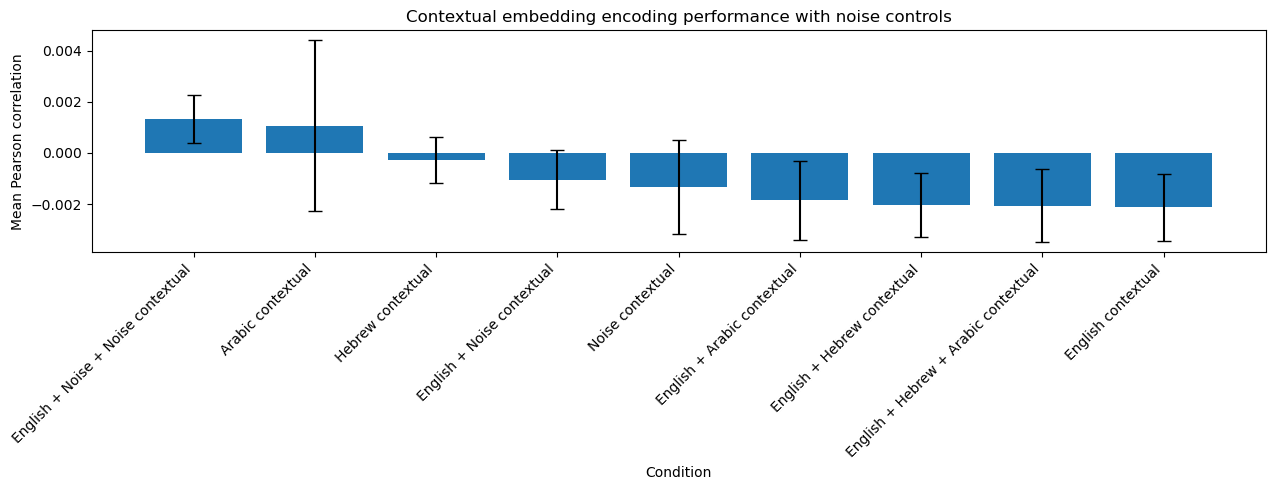

Saved plot to:
C:\Users\mayat\OneDrive\Desktop\lab\Language-Project-main\data\processed\encoding_results_contextual_pseudo_sentence_WITH_NOISE_32Hz_(-1.0,1.0)\contextual_encoding_barplot_WITH_NOISE.png


In [10]:
# =========================
# Cell 10: Bar plot
# =========================

plot_df = condition_summary.sort_values("mean_across_subjects", ascending=False)

plt.figure(figsize=(13, 5))

plt.bar(
    plot_df["condition"],
    plot_df["mean_across_subjects"],
    yerr=plot_df["sem_across_subjects"],
    capsize=5,
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean Pearson correlation")
plt.xlabel("Condition")
plt.title("Contextual embedding encoding performance with noise controls")
plt.tight_layout()

plot_path = os.path.join(OUT_DIR, "contextual_encoding_barplot_WITH_NOISE.png")
plt.savefig(plot_path, dpi=300)
plt.show()

print("Saved plot to:")
print(plot_path)

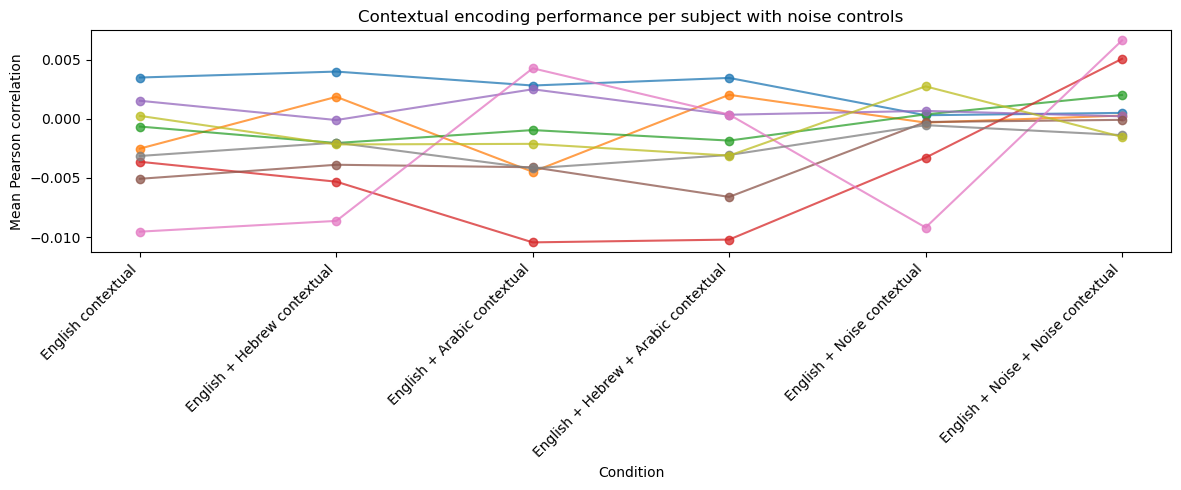

Saved plot to:
C:\Users\mayat\OneDrive\Desktop\lab\Language-Project-main\data\processed\encoding_results_contextual_pseudo_sentence_WITH_NOISE_32Hz_(-1.0,1.0)\contextual_encoding_per_subject_lines_WITH_NOISE.png


In [11]:
# =========================
# Cell 11: Per-subject line plot
# =========================

pivot = results_contextual_all_subjects.pivot(
    index="subject",
    columns="condition",
    values="mean_corr",
)

conditions_to_plot = [
    "English contextual",
    "English + Hebrew contextual",
    "English + Arabic contextual",
    "English + Hebrew + Arabic contextual",
    "English + Noise contextual",
    "English + Noise + Noise contextual",
]

conditions_to_plot = [c for c in conditions_to_plot if c in pivot.columns]

plt.figure(figsize=(12, 5))

for subj in pivot.index:
    y = pivot.loc[subj, conditions_to_plot].values
    x = range(len(conditions_to_plot))
    plt.plot(x, y, marker="o", alpha=0.75)

plt.xticks(
    range(len(conditions_to_plot)),
    conditions_to_plot,
    rotation=45,
    ha="right",
)

plt.ylabel("Mean Pearson correlation")
plt.xlabel("Condition")
plt.title("Contextual encoding performance per subject with noise controls")
plt.tight_layout()

plot_path = os.path.join(OUT_DIR, "contextual_encoding_per_subject_lines_WITH_NOISE.png")
plt.savefig(plot_path, dpi=300)
plt.show()

print("Saved plot to:")
print(plot_path)

In [12]:
# =========================
# Cell 12: Paired comparisons
# =========================

pivot = results_contextual_all_subjects.pivot(
    index="subject",
    columns="condition",
    values="mean_corr",
)

comparisons = [
    ("English + Hebrew contextual", "English contextual"),
    ("English + Arabic contextual", "English contextual"),
    ("English + Hebrew + Arabic contextual", "English contextual"),
    ("English + Hebrew contextual", "English + Noise contextual"),
    ("English + Arabic contextual", "English + Noise contextual"),
    ("English + Hebrew + Arabic contextual", "English + Noise + Noise contextual"),
]

paired_rows = []

for test_condition, baseline_condition in comparisons:
    if test_condition not in pivot.columns or baseline_condition not in pivot.columns:
        continue

    paired = pivot[[test_condition, baseline_condition]].dropna()
    if len(paired) < 2:
        paired_rows.append({
            "test_condition": test_condition,
            "baseline_condition": baseline_condition,
            "n_subjects": len(paired),
            "mean_diff": np.nan,
            "ttest_p": np.nan,
            "wilcoxon_p": np.nan,
            "note": "Not enough subjects for statistical test",
        })
        continue

    diff = paired[test_condition] - paired[baseline_condition]

    t_stat, t_p = ttest_rel(paired[test_condition], paired[baseline_condition])

    try:
        w_stat, w_p = wilcoxon(paired[test_condition], paired[baseline_condition])
    except ValueError:
        w_p = np.nan

    paired_rows.append({
        "test_condition": test_condition,
        "baseline_condition": baseline_condition,
        "n_subjects": len(paired),
        "mean_test": paired[test_condition].mean(),
        "mean_baseline": paired[baseline_condition].mean(),
        "mean_diff": diff.mean(),
        "median_diff": diff.median(),
        "n_positive_diff": int((diff > 0).sum()),
        "n_negative_diff": int((diff < 0).sum()),
        "ttest_p": t_p,
        "wilcoxon_p": w_p,
        "note": "",
    })

paired_tests = pd.DataFrame(paired_rows)

paired_path = os.path.join(OUT_DIR, "contextual_encoding_paired_tests_WITH_NOISE.csv")
paired_tests.to_csv(paired_path, index=False, encoding="utf-8-sig")

print("Saved paired tests to:")
print(paired_path)

display(paired_tests)

Saved paired tests to:
C:\Users\mayat\OneDrive\Desktop\lab\Language-Project-main\data\processed\encoding_results_contextual_pseudo_sentence_WITH_NOISE_32Hz_(-1.0,1.0)\contextual_encoding_paired_tests_WITH_NOISE.csv


,test_condition,baseline_condition,n_subjects,mean_test,mean_baseline,mean_diff,median_diff,n_positive_diff,n_negative_diff,ttest_p,wilcoxon_p,note
0,English + Hebrew contextual,English contextual,9,-0.002026,-0.002135,0.000109,0.000504,5,4,0.881477,0.734375,
1,English + Arabic contextual,English contextual,9,-0.001846,-0.002135,0.000290,-0.000677,3,6,0.880448,0.496094,
2,English + Hebrew + Arabic contextual,English contextual,9,-0.002062,-0.002135,0.000073,-0.001183,3,6,0.964045,0.652344,
3,English + Hebrew contextual,English + Noise contextual,9,-0.002026,-0.001046,-0.000980,-0.001478,3,6,0.315207,0.359375,
4,English + Arabic contextual,English + Noise contextual,9,-0.001846,-0.001046,-0.000800,-0.003655,3,6,0.709234,0.359375,
5,English + Hebrew + Arabic contextual,English + Noise + Noise contextual,9,-0.002062,0.001316,-0.003378,-0.001683,3,6,0.105091,0.164062,


## How to interpret the noise controls

Key comparisons:

1. **English + Hebrew contextual vs English contextual**  
   Tests whether adding Hebrew improves over English alone.

2. **English + Hebrew contextual vs English + Noise contextual**  
   Tests whether Hebrew helps more than adding the same number of random dimensions.

3. **English + Arabic contextual vs English + Noise contextual**  
   Tests whether Arabic helps more than adding the same number of random dimensions.

4. **English + Hebrew + Arabic contextual vs English + Noise + Noise contextual**  
   Tests whether adding both non-English languages helps more than adding two random noise blocks.

If a multilingual condition is not better than its matched noise condition, then any improvement may be due to dimensionality rather than meaningful cross-lingual semantic information.


In [17]:
# =========================
# Threshold-selected electrodes analysis
# =========================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = r"C:\Users\mayat\OneDrive\Desktop\lab\Language-Project-main"

outpath = rf"{PROJECT_ROOT}\data\processed\encoding_results_contextual_pseudo_sentence_WITH_NOISE_32Hz_(-1.0,1.0)"

subjects = [f"{i:02d}" for i in range(1, 10)]

print("Using output directory:")
print(outpath)
print("Exists:", os.path.exists(outpath))

# -------------------------
# Choose threshold
# -------------------------
# This means: select electrodes whose best English contextual score
# across time is greater than this threshold.
threshold = 0.1   # You can also try 0.01 later

# Select electrodes based on English contextual only
# This avoids choosing electrodes based on the condition we want to prove.
selection_condition_key = "en"

condition_files = {
    "English contextual": "en",
    "Hebrew contextual": "he",
    "Arabic contextual": "ar",
    "English + Hebrew contextual": "en_plus_he",
    "English + Arabic contextual": "en_plus_ar",
    "English + Hebrew + Arabic contextual": "all",
    "Noise contextual": "noise",
    "English + Noise contextual": "en_plus_noise",
    "English + Noise + Noise contextual": "en_plus_noise_plus_noise",
}

selected_rows = []

for subj in subjects:
    print("\n" + "=" * 70)
    print(f"Subject {subj}")
    print("=" * 70)

    # Load English contextual scores for electrode selection
    en_path = os.path.join(outpath, f"contextual_scores_sub{subj}_{selection_condition_key}.npy")

    if not os.path.exists(en_path):
        print(f"Missing English baseline for subject {subj}, skipping.")
        continue

    scores_en = np.load(en_path)  # shape: folds × electrodes × time
    print("English scores shape:", scores_en.shape)

    # Average across folds -> electrodes × time
    scores_en_mean = np.nanmean(scores_en, axis=0)

    # For each electrode, take its best time point
    best_per_electrode = np.nanmax(scores_en_mean, axis=1)

    # Select electrodes by fixed threshold
    selected_mask = best_per_electrode > threshold
    n_selected = int(selected_mask.sum())
    n_total = int(len(selected_mask))

    print(f"Selected electrodes: {n_selected} / {n_total}")
    print(f"Threshold: max English contextual r > {threshold}")

    for condition_name, condition_key in condition_files.items():
        score_path = os.path.join(outpath, f"contextual_scores_sub{subj}_{condition_key}.npy")

        if not os.path.exists(score_path):
            print(f"Missing file for {condition_name}: {score_path}")
            continue

        scores = np.load(score_path)  # folds × electrodes × time

        if n_selected == 0:
            mean_selected = np.nan
            median_selected = np.nan
            max_selected = np.nan
        else:
            selected_scores = scores[:, selected_mask, :]
            mean_selected = np.nanmean(selected_scores)
            median_selected = np.nanmedian(selected_scores)
            max_selected = np.nanmax(selected_scores)

        selected_rows.append({
            "subject": subj,
            "condition": condition_name,
            "condition_key": condition_key,
            "threshold": threshold,
            "selection_based_on": "English contextual",
            "n_selected_electrodes": n_selected,
            "n_total_electrodes": n_total,
            "mean_corr_selected_electrodes": mean_selected,
            "median_corr_selected_electrodes": median_selected,
            "max_corr_selected_electrodes": max_selected,
        })

selected_results = pd.DataFrame(selected_rows)

selected_results_path = os.path.join(
    outpath,
    f"contextual_encoding_selected_electrodes_threshold_{threshold}.csv"
)

selected_results.to_csv(selected_results_path, index=False, encoding="utf-8-sig")

print("\nSaved selected-electrode results to:")
print(selected_results_path)

display(selected_results)

Using output directory:
C:\Users\mayat\OneDrive\Desktop\lab\Language-Project-main\data\processed\encoding_results_contextual_pseudo_sentence_WITH_NOISE_32Hz_(-1.0,1.0)
Exists: True

Subject 01
English scores shape: (2, 99, 64)
Selected electrodes: 12 / 99
Threshold: max English contextual r > 0.1

Subject 02
English scores shape: (2, 90, 64)
Selected electrodes: 10 / 90
Threshold: max English contextual r > 0.1

Subject 03
English scores shape: (2, 235, 64)
Selected electrodes: 26 / 235
Threshold: max English contextual r > 0.1

Subject 04
English scores shape: (2, 143, 64)
Selected electrodes: 9 / 143
Threshold: max English contextual r > 0.1

Subject 05
English scores shape: (2, 159, 64)
Selected electrodes: 9 / 159
Threshold: max English contextual r > 0.1

Subject 06
English scores shape: (2, 166, 64)
Selected electrodes: 10 / 166
Threshold: max English contextual r > 0.1

Subject 07
English scores shape: (2, 116, 64)
Selected electrodes: 9 / 116
Threshold: max English contextual r

,subject,condition,condition_key,threshold,selection_based_on,n_selected_electrodes,n_total_electrodes,mean_corr_selected_electrodes,median_corr_selected_electrodes,max_corr_selected_electrodes
0,01,English contextual,en,0.1,English contextual,12,99,0.011699,0.011307,0.153177
1,01,Hebrew contextual,he,0.1,English contextual,12,99,-0.002285,-0.003252,0.115000
2,01,Arabic contextual,ar,0.1,English contextual,12,99,-0.000010,0.000769,0.107124
3,01,English + Hebrew contextual,en_plus_he,0.1,English contextual,12,99,0.008777,0.009441,0.126886
4,01,English + Arabic contextual,en_plus_ar,0.1,English contextual,12,99,0.008203,0.006887,0.155030
...,...,...,...,...,...,...,...,...,...,...
76,09,English + Arabic contextual,en_plus_ar,0.1,English contextual,17,188,0.000363,-0.001106,0.121347
77,09,English + Hebrew + Arabic contextual,all,0.1,English contextual,17,188,-0.000340,0.001245,0.124549
78,09,Noise contextual,noise,0.1,English contextual,17,188,0.002928,0.002938,0.108187
79,09,English + Noise contextual,en_plus_noise,0.1,English contextual,17,188,0.004316,0.004208,0.109506


Saved selected-electrode condition summary to:
C:\Users\mayat\OneDrive\Desktop\lab\Language-Project-main\data\processed\encoding_results_contextual_pseudo_sentence_WITH_NOISE_32Hz_(-1.0,1.0)\contextual_encoding_selected_electrodes_condition_summary_threshold_0.1.csv


,condition,mean_across_subjects,std_across_subjects,n_subjects,mean_n_selected_electrodes,sem_across_subjects
6,English contextual,0.003007,0.003625,9,12.111111,0.001208
1,English + Arabic contextual,0.002168,0.003162,9,12.111111,0.001054
3,English + Hebrew contextual,0.001833,0.002983,9,12.111111,0.000994
2,English + Hebrew + Arabic contextual,0.001665,0.003441,9,12.111111,0.001147
4,English + Noise + Noise contextual,0.001004,0.002217,9,12.111111,0.000739
5,English + Noise contextual,0.000239,0.002323,9,12.111111,0.000774
0,Arabic contextual,0.000220,0.003071,9,12.111111,0.001024
8,Noise contextual,0.000167,0.002920,9,12.111111,0.000973
7,Hebrew contextual,-0.000276,0.002178,9,12.111111,0.000726


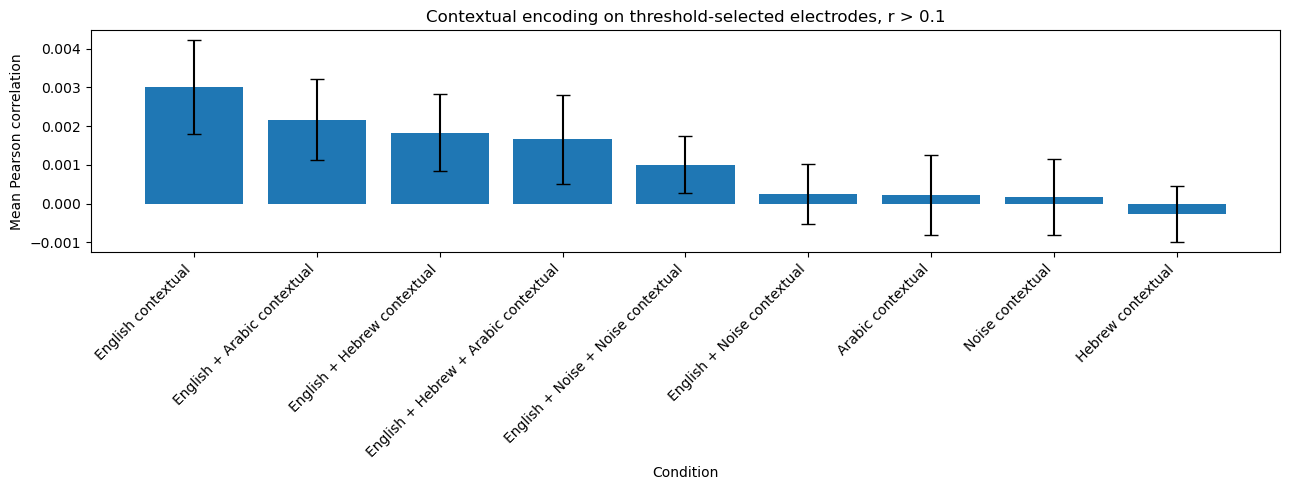

Saved plot to:
C:\Users\mayat\OneDrive\Desktop\lab\Language-Project-main\data\processed\encoding_results_contextual_pseudo_sentence_WITH_NOISE_32Hz_(-1.0,1.0)\contextual_encoding_selected_electrodes_barplot_threshold_0.1.png


In [18]:
# =========================
# Summary + plot after threshold selection
# =========================

selected_condition_summary = (
    selected_results
    .groupby("condition", as_index=False)
    .agg(
        mean_across_subjects=("mean_corr_selected_electrodes", "mean"),
        std_across_subjects=("mean_corr_selected_electrodes", "std"),
        n_subjects=("mean_corr_selected_electrodes", "count"),
        mean_n_selected_electrodes=("n_selected_electrodes", "mean")
    )
)

selected_condition_summary["sem_across_subjects"] = (
    selected_condition_summary["std_across_subjects"] /
    np.sqrt(selected_condition_summary["n_subjects"])
)

selected_condition_summary = selected_condition_summary.sort_values(
    "mean_across_subjects",
    ascending=False
)

selected_summary_path = os.path.join(
    outpath,
    f"contextual_encoding_selected_electrodes_condition_summary_threshold_{threshold}.csv"
)

selected_condition_summary.to_csv(
    selected_summary_path,
    index=False,
    encoding="utf-8-sig"
)

print("Saved selected-electrode condition summary to:")
print(selected_summary_path)

display(selected_condition_summary)

# Plot
plot_df = selected_condition_summary.sort_values(
    "mean_across_subjects",
    ascending=False
)

plt.figure(figsize=(13, 5))

plt.bar(
    plot_df["condition"],
    plot_df["mean_across_subjects"],
    yerr=plot_df["sem_across_subjects"],
    capsize=5
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean Pearson correlation")
plt.xlabel("Condition")
plt.title(f"Contextual encoding on threshold-selected electrodes, r > {threshold}")
plt.tight_layout()

plot_path = os.path.join(
    outpath,
    f"contextual_encoding_selected_electrodes_barplot_threshold_{threshold}.png"
)

plt.savefig(plot_path, dpi=300)
plt.show()

print("Saved plot to:")
print(plot_path)

In [ ]:
# =========================
# Time-course plot: contextual encoding on threshold-selected electrodes
# =========================

import os
import numpy as np
import matplotlib.pyplot as plt

# If outpath is not defined, set it manually:
PROJECT_ROOT = r"C:\Users\mayat\OneDrive\Desktop\lab\Language-Project-main"

outpath = rf"{PROJECT_ROOT}\data\processed\encoding_results_contextual_pseudo_sentence_WITH_NOISE_32Hz_(-1.0,1.0)"

# Subjects and parameters
subjects = [f"{i:02d}" for i in range(1, 10)]

freq = 32
tmin, tmax = -1.0, 1.0
threshold = 0.005

# Conditions to plot
conditions = {
    "English": "en",
    "Hebrew": "he",
    "Arabic": "ar",
    "EN+HE": "en_plus_he",
    "EN+AR": "en_plus_ar",
    "EN+HE+AR": "all",
    "Noise": "noise",
    "EN+Noise": "en_plus_noise",
    "EN+Noise+Noise": "en_plus_noise_plus_noise",
}

# Optional visual style similar to the example
line_styles = {
    "English": {"color": "black", "linestyle": "-", "linewidth": 2.0},
    "Hebrew": {"color": "royalblue", "linestyle": "-", "linewidth": 2.0},
    "Arabic": {"color": "firebrick", "linestyle": "-", "linewidth": 2.0},
    "EN+HE": {"color": "royalblue", "linestyle": "--", "linewidth": 2.0},
    "EN+AR": {"color": "firebrick", "linestyle": "--", "linewidth": 2.0},
    "EN+HE+AR": {"color": "purple", "linestyle": "-", "linewidth": 2.0},
    "Noise": {"color": "gray", "linestyle": ":", "linewidth": 2.0},
    "EN+Noise": {"color": "gray", "linestyle": "--", "linewidth": 2.0},
    "EN+Noise+Noise": {"color": "gray", "linestyle": "-", "linewidth": 2.0},
}

# Store selected scores for each condition
# Each value will become: observations × time
condition_observations = {name: [] for name in conditions}

selected_counts = []

for subj in subjects:
    # Select electrodes based on English contextual only
    en_path = os.path.join(outpath, f"contextual_scores_sub{subj}_en.npy")
    
    if not os.path.exists(en_path):
        print(f"Missing English file for subject {subj}, skipping.")
        continue
    
    scores_en = np.load(en_path)  # folds × electrodes × time
    scores_en_mean = np.nanmean(scores_en, axis=0)  # electrodes × time
    
    best_per_electrode = np.nanmax(scores_en_mean, axis=1)
    selected_mask = best_per_electrode > threshold
    
    n_selected = int(selected_mask.sum())
    n_total = int(len(selected_mask))
    selected_counts.append((subj, n_selected, n_total))
    
    print(f"Subject {subj}: selected {n_selected}/{n_total} electrodes")
    
    if n_selected == 0:
        continue
    
    for condition_name, condition_key in conditions.items():
        path = os.path.join(outpath, f"contextual_scores_sub{subj}_{condition_key}.npy")
        
        if not os.path.exists(path):
            print(f"Missing {condition_name} for subject {subj}: {path}")
            continue
        
        scores = np.load(path)  # folds × electrodes × time
        
        # Select electrodes, keep folds and time
        selected_scores = scores[:, selected_mask, :]  # folds × selected_electrodes × time
        
        # Convert to observations × time
        obs_by_time = selected_scores.reshape(-1, selected_scores.shape[-1])
        
        condition_observations[condition_name].append(obs_by_time)

# Build lag axis
# Number of timepoints from any available condition
example_key = next(
    name for name, arrays in condition_observations.items()
    if len(arrays) > 0
)
n_times = condition_observations[example_key][0].shape[1]
lags = tmin + np.arange(n_times) / freq

# Plot
plt.figure(figsize=(13, 5))

for condition_name, arrays in condition_observations.items():
    if len(arrays) == 0:
        continue
    
    data = np.vstack(arrays)  # observations × time
    
    mean = np.nanmean(data, axis=0)
    sem = np.nanstd(data, axis=0, ddof=1) / np.sqrt(data.shape[0])
    
    style = line_styles.get(condition_name, {})
    
    plt.plot(
        lags,
        mean,
        label=condition_name,
        **style
    )
    
    plt.fill_between(
        lags,
        mean - sem,
        mean + sem,
        alpha=0.12,
        color=style.get("color", None)
    )

plt.axvline(0, color="gray", linestyle="--", linewidth=1)
plt.axhline(0, color="gray", linestyle="--", linewidth=1)

plt.xlabel("Lag (s)")
plt.ylabel("Encoding performance (r ± SEM)")
plt.title(f"Contextual encoding — threshold-selected electrodes, r > {threshold}")
plt.legend(loc="upper left", fontsize=9)
plt.tight_layout()

plot_path = os.path.join(
    outpath,
    f"contextual_encoding_timecourse_selected_electrodes_threshold_{threshold}.png"
)

plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot to:")
print(plot_path)

print("\nSelected electrode counts:")
for subj, n_selected, n_total in selected_counts:
    print(f"Subject {subj}: {n_selected}/{n_total}")